# Week 2 Day 4 — Model Evaluation Metrics

## Key insight — accuracy is misleading on imbalanced data:
- Dummy classifier scored 0.90 accuracy (predicts 0 always)
- Real model scored 0.895 accuracy
- But real model catches 30% of positives vs dummy's 0%
- AUC = 0.86 — much better metric for imbalanced data

## Classification metrics:
- Accuracy  → useless when classes are imbalanced
- Precision → when false alarms are costly
- Recall    → when missing positives is dangerous  
- F1        → balance between precision and recall
- AUC-ROC   → best single metric for imbalanced classification

## Regression metrics:
- MAE  = 0.5332 → avg error $53,320 — treats all errors equally
- RMSE = 0.7456 → penalizes large errors more heavily
- R²   = 0.5758 → model explains 57.58% of variance
         (linear model limited — Random Forest will do better)

## When to use which metric:
- Cancer/fraud detection → maximize Recall
- Spam filter            → maximize Precision  
- General classification → F1 score
- Regression             → RMSE (large errors matter) or MAE (equal errors)

# Demonstrate why accuracy is useless on imbalanced data:

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# imbalanced dataset — 90% class 0, 10% class 1
X, y = make_classification(n_samples=1000, weights=[0.9, 0.1], 
                            random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

# train logistic regression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

# dummy — always predicts majority class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_val)

print("=" * 45)
print("   IMBALANCED DATA — ACCURACY IS MISLEADING")
print("=" * 45)
print(f"  Dummy accuracy    : {accuracy_score(y_val, y_dummy):.4f}")
print(f"  Model accuracy    : {accuracy_score(y_val, y_pred):.4f}")
print("=" * 45)
print("\nFull classification report:")
print(classification_report(y_val, y_pred))

   IMBALANCED DATA — ACCURACY IS MISLEADING
  Dummy accuracy    : 0.9000
  Model accuracy    : 0.8950

Full classification report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       180
           1       0.46      0.30      0.36        20

    accuracy                           0.90       200
   macro avg       0.69      0.63      0.65       200
weighted avg       0.88      0.90      0.88       200



# Plot confusion matrix:

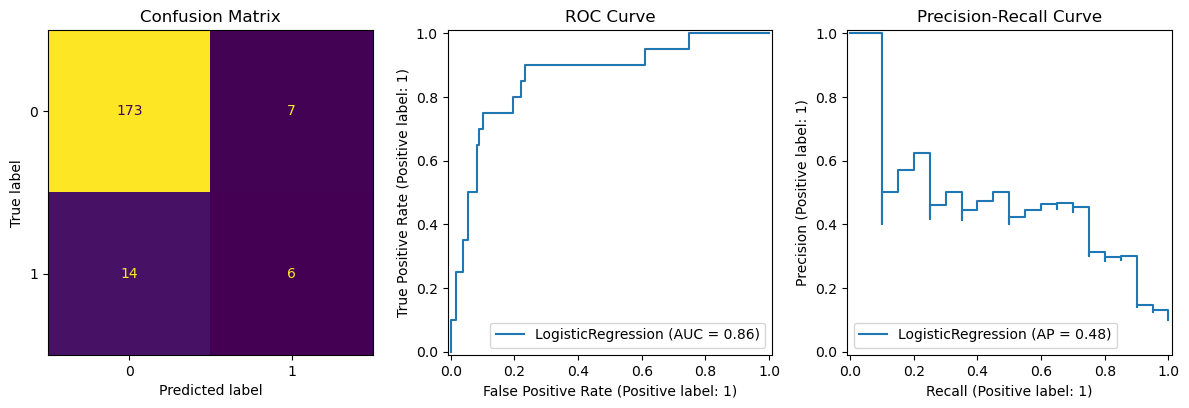

In [2]:
plt.figure(figsize=(12, 4))

# confusion matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix')

# ROC curve
plt.subplot(1, 3, 2)
RocCurveDisplay.from_estimator(model, X_val, y_val, ax=plt.gca())
plt.title('ROC Curve')

# Precision-Recall curve
plt.subplot(1, 3, 3)
PrecisionRecallDisplay.from_estimator(model, X_val, y_val, ax=plt.gca())
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Regression metrics on California Housing:

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X, y = housing.data, housing.target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_val)

mae  = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2   = r2_score(y_val, y_pred)

print("=" * 45)
print("   REGRESSION METRICS — California Housing")
print("=" * 45)
print(f"  MAE  : {mae:.4f}  (avg error in $100k)")
print(f"  RMSE : {rmse:.4f}  (penalizes large errors more)")
print(f"  R²   : {r2:.4f}  (variance explained)")
print("=" * 45)

   REGRESSION METRICS — California Housing
  MAE  : 0.5332  (avg error in $100k)
  RMSE : 0.7456  (penalizes large errors more)
  R²   : 0.5758  (variance explained)
